# Jupyter Notebook: Linear regression

## Step 1: Install Required Libraries

First, ensure you have the necessary libraries installed. You can install them using the following command:

`pip install pandas numpy seaborn matplotlib scikit-learn`

Download the dataset from [Kaggle](https://www.kaggle.com/competitions/home-data-for-ml-course/data)



In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 2: Load the Dataset

In [18]:
# Load the dataset
df = pd.read_csv(r"train.csv") # Update to the path of your file


# Display the first few rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Step 3: Data preprocessing
As always, before training any AI algorithm, we need to clean the dataset, we are going to:
- Handle missing values
- Convert categorical variables to numerical format
- Select relevant features


In [19]:
# Check for missing values
print(df.isnull().sum())

# Select columns by semantic dtype for better pandas compatibility
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object', 'string', 'category']).columns

# Fill missing values (if any) with median for numerical columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing values for categorical columns with mode
for col in categorical_cols:
    mode = df[col].mode(dropna=True)
    if not mode.empty:
        df[col] = df[col].fillna(mode.iloc[0])

# Convert categorical columns using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Drop the ID column
df = df.drop('Id', axis=1)

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


## Step 4: Spliting the data 
Dividing the data into train and validation sets (Kaggle has already separated a test set) 

In [20]:
# Define target variable and features
y = df['SalePrice']
X = df.drop(columns=['SalePrice'])

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the new datasets
X_train.shape, X_test.shape

((1168, 244), (292, 244))

## Step 5: Training the Linear Regression Model

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 6: Prediction on the validation set


In [22]:
y_pred = model.predict(X_test)

## Step 7: Visualization of results
A scatter plot of actual vs. predicted values can help us see how well the model performs.

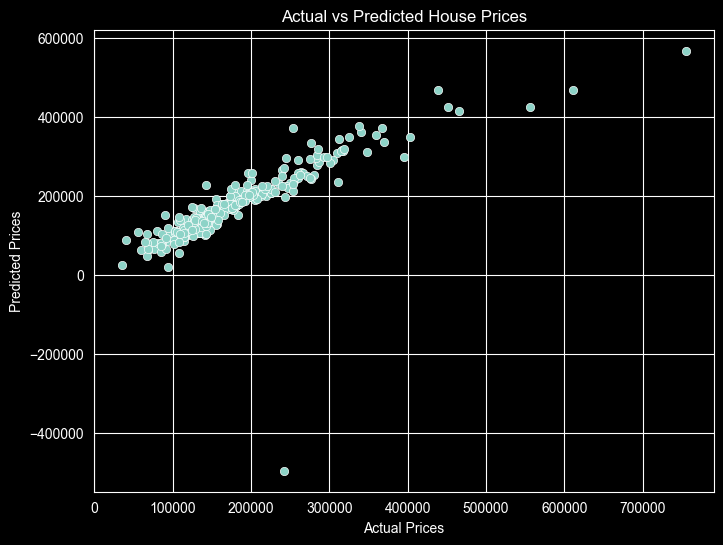

In [23]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Step 8: Calculate the performance of the model
We are going to use some numerical metrics to calculate the performance of the algorithm

In [24]:
# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 20236.406098241656


## Investigation tasks

**Task 1**: Interpret the scatter plot tell in terms of the performance of the model.

<span style="color:red">(1 mark)</span>

The prediction prices are mainly correct, however there is one critical error in the graph as at around 230,000 dollars it missed the price prediction by 700,000. Therefore the performance is up to standard but it is not fully accurate, but that can be expected as there will always be an outlier.

**Task 2**: Calculate the mean squared error and the R-squared score. Explain what these metrics represent and use them to justify if the model makes good predictions.

<span style="color:red">(2 marks)</span>

In [25]:
square = mean_squared_error(y_test, y_pred)
triangle = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {square}")
print(f"R-Squared Score: {triangle}")

Mean Squared Error: 2641205374.231982
R-Squared Score: 0.6556593157984386


In my opinion r-squared score indicates that the data fit is poor, as scores below 0.7 means it is not a good fit, in addition to this, this is probably caused by the outlier, resulting in the score being significantly below expected.

**Task 3**: Use the trained Linear Regression model to make predictions on the training data. Then, visualize the actual vs. predicted prices using a scatter plot. Additionally, calculate and interpret the model's performance metrics, including Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared score.

<span style="color:red">(1 mark)</span>

Training MAE: 12698.120293036858
Training MSE: 382336962.3332065
Training R-Squared: 0.9358984436396163


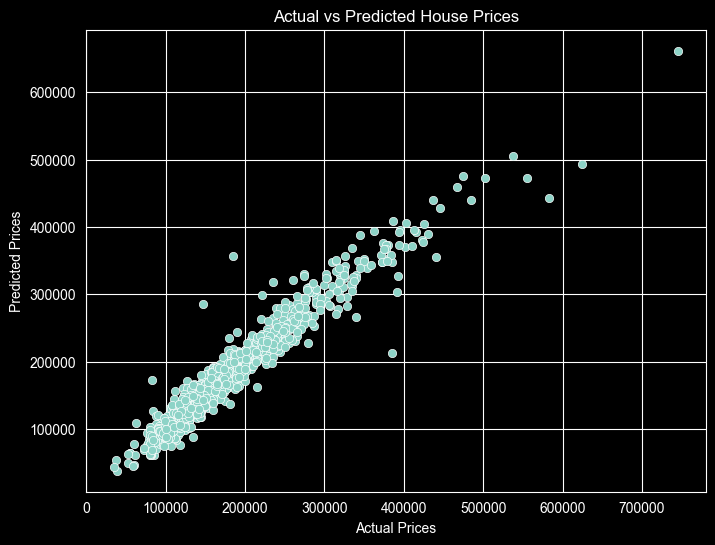

In [26]:
y_train_pred = model.predict(X_train)

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_train, y=y_train_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Training MAE: {train_mae}")
print(f"Training MSE: {train_mse}")
print(f"Training R-Squared: {train_r2}")

plt.show()

The R-Squared data shows that the data has a high rate of accuracy compared than the one trained on test data, furthermore the MAE is almost halved therefore showing a good fit.


**Task 4**: Compare the model's performance on the training set and the validation set using the evaluation metrics. Based on these results, determine whether the model is underfitting or overfitting. Justify your answer by explaining the observed differences in error values.

<span style="color:red">(1 mark)</span>

The model has a high has a high rate of  accuracy on the training set, therefore it is a good predictiction. However it is most likely overfitting as for 0.93 it is too well for a data line. With the MAE being only 12698, being significantly low.

**Bonus:**: Improve the data cleaning steps, and evaluate whether these improvements lead to better model performance.

<span style="color:red">(1 mark)</span>

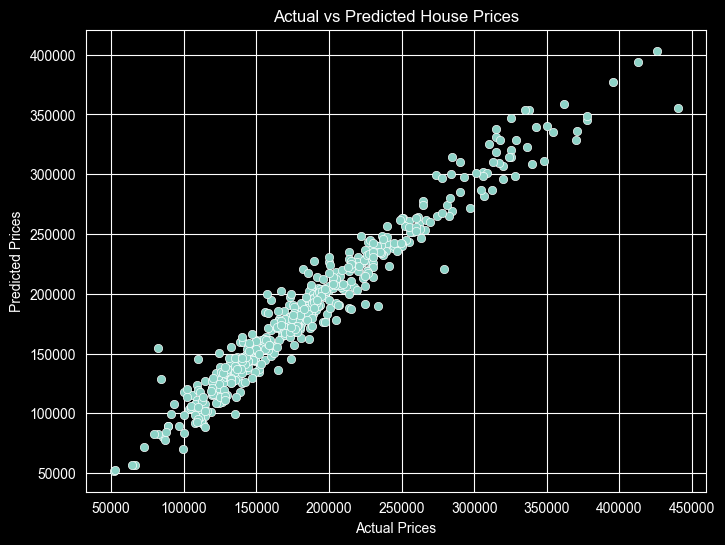

Mean Squared Error: 199282530.8256161
R-Squared Score: 0.9537476855883391


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv(r"train.csv")

numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object', 'string', 'category']).columns

# Drop missing values
numeric_cols_missing = [column for column in numeric_cols if df[column].isna().any()]
df = df.drop(columns=numeric_cols_missing)

#Drop missing values for categorical columns
numeric_categorical_missing = [column for column in categorical_cols if df[column].isna().any()]
df = df.drop(columns=numeric_categorical_missing)

# IQR Thing, Needed help from copilot THIS IS NOT FULLY MY CODE
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('SalePrice', errors='ignore')

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outlier = ~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
df = df.loc[outlier].copy()

# Convert categorical columns using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Drop the ID column
df = df.drop('Id', axis=1)

# Define target variable and features
y = df['SalePrice']
X = df.drop(columns=['SalePrice'])

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the new datasets
X_train.shape, X_test.shape

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_train)

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_train, y=y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

square = mean_squared_error(y_train, y_pred)
triangle = r2_score(y_train, y_pred)
print(f"Mean Squared Error: {square}")
print(f"R-Squared Score: {triangle}")


By dropping the outliers, and also dropping missing data and not filling it with median, as doing so can skewer and influence the data, our r-squared score is now 0.95, significantly higher than the previous 0.655, showing how such actions resulted in better model performance.

**Bonus:**: Make predictions on the test set and submit your results on Kaggle to evaluate the model's performance. Ensure that you apply the same data preprocessing steps to the test data as you did for the training data to maintain consistency and accuracy.

<span style="color:red">(1 mark)</span>

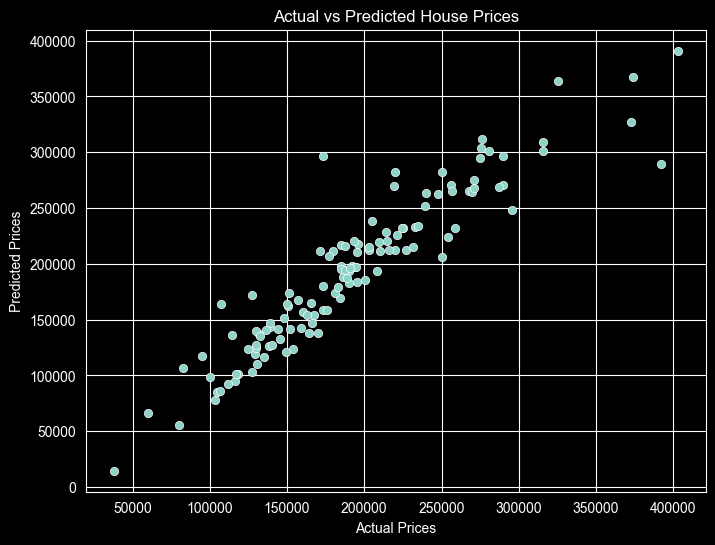

Mean Squared Error: 622070311.6509576
R-Squared Score: 0.862870181503107


In [35]:
y_pred = model.predict(X_test)

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

square = mean_squared_error(y_test, y_pred)
triangle = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {square}")
print(f"R-Squared Score: {triangle}")


Kaggle Score is in README